In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [2]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [3]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [4]:
#experiment_directory = "examples/torus/Run_w_con_loss_one_variable_usual"
experiment_directory = "examples/hippocampus_MS"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/obj_files")

In [5]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_directory, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["disease"] = int(label[1].item())  # disease info at index 1
            params["age"] = float(label[0].item())   # age info at index 0
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["disease"] = 0
            params["age"] = 0.0
        mesh_params.append(params)

Loading labels from /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/labels.pt
All labels: {'ab300_001': array([0.34117647, 0.        ]), 'ab300_003': array([0.41176471, 0.        ]), 'ab300_004': array([0.56470588, 0.        ]), 'ab300_007': array([0.61176471, 0.        ]), 'ab300_008': array([0.32941176, 0.        ]), 'ab300_009': array([0.70588235, 0.        ]), 'ab300_010': array([0.35294118, 0.        ]), 'ab300_011': array([0.72941176, 0.        ]), 'ab300_015': array([0.34117647, 0.        ]), 'ab300_016': array([0.62352941, 0.        ]), 'ab300_021': array([0.56470588, 0.        ]), 'ab300_022': array([0.63529412, 0.        ]), 'ab300_024': array([0.42352941, 0.        ]), 'ab300_026': array([0.51764706, 0.        ]), 'ab300_027': array([0.50588235, 0.        ]), 'ab300_029': array([0.71764706, 0.        ]), 'ab300_031': array([0.50588235, 0.        ]), 'ab300_033': array([0.43529412, 0.        ]), 'ab300_0

In [7]:
test_labels = torch.load(labels_path)
test_labels

{'ab300_001': array([0.34117647, 0.        ]),
 'ab300_003': array([0.41176471, 0.        ]),
 'ab300_004': array([0.56470588, 0.        ]),
 'ab300_007': array([0.61176471, 0.        ]),
 'ab300_008': array([0.32941176, 0.        ]),
 'ab300_009': array([0.70588235, 0.        ]),
 'ab300_010': array([0.35294118, 0.        ]),
 'ab300_011': array([0.72941176, 0.        ]),
 'ab300_015': array([0.34117647, 0.        ]),
 'ab300_016': array([0.62352941, 0.        ]),
 'ab300_021': array([0.56470588, 0.        ]),
 'ab300_022': array([0.63529412, 0.        ]),
 'ab300_024': array([0.42352941, 0.        ]),
 'ab300_026': array([0.51764706, 0.        ]),
 'ab300_027': array([0.50588235, 0.        ]),
 'ab300_029': array([0.71764706, 0.        ]),
 'ab300_031': array([0.50588235, 0.        ]),
 'ab300_033': array([0.43529412, 0.        ]),
 'ab300_035': array([0.65882353, 0.        ]),
 'ab300_036': array([0.76470588, 0.        ]),
 'ab300_037': array([0.32941176, 0.        ]),
 'ab300_038':

In [8]:
# Extract parameters for visualization
has_disease = np.array([p.get("disease", 0) for p in mesh_params])
ages = np.array([p.get("age", 0.0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_disease, ages))
factor_names = ["disease", "age"]

In [9]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [10]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [11]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_latents = []

In [12]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [14]:
#eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, train_split)
labels = torch.load(data_source + "/labels.pt")
#eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [14]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[1])
    all_labels_reg.append(label[0])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "all_unsupervised_hippo", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_246.npz...


Mesh creation for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_246.npz took 6.795108318328857 seconds.
Creating mesh for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_201.npz...
Mesh creation for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_201.npz took 4.591025352478027 seconds.
Creating mesh for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_212.npz...
Mesh creation for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_files/ab300_212.npz took 4.494468450546265 seconds.
Creating mesh for /home/jakaria/hippocampus_data_tle_ms_age_and_0_1/hippoData_regstrd_disease_reconstrct_ply/sdf_data/SdfSamples/obj_

In [15]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/hippocampus_MS/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/hippocampus_MS/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/hippocampus_MS/metrics/all_latents.npy


In [15]:
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (196, 1, 16)


In [16]:
all_latents_array = all_latents_array.squeeze()
X = all_latents_array

In [17]:
# Calculate correlations between each latent dimension and both labels
print("CORRELATION ANALYSIS: 16 Latent Dimensions vs Age and Disease")
print("="*70)

# Initialize arrays to store correlations
age_correlations = []
disease_correlations = []

print(f"Latent space shape: {X.shape}")
print(f"Age labels shape: {ages.shape}")
print(f"Disease labels shape: {has_disease.shape}")
print()

# Calculate correlation for each latent dimension
for dim in range(X.shape[1]):
    # Correlation with age
    age_corr = np.corrcoef(X[:, dim], ages)[0, 1]
    age_correlations.append(age_corr)
    
    # Correlation with disease
    disease_corr = np.corrcoef(X[:, dim], has_disease)[0, 1]
    disease_correlations.append(disease_corr)
    
    print(f"Latent Dimension {dim+1:2d}:")
    print(f"  Age correlation:     {age_corr:8.4f}")
    print(f"  Disease correlation: {disease_corr:8.4f}")
    print()

# Convert to numpy arrays for easier analysis
age_correlations = np.array(age_correlations)
disease_correlations = np.array(disease_correlations)

# Summary analysis
print("SUMMARY ANALYSIS:")
print("="*50)

# Find dimensions with highest correlations
best_age_dim = np.argmax(np.abs(age_correlations))
best_disease_dim = np.argmax(np.abs(disease_correlations))

print(f"Best dimension for AGE:     Dim {best_age_dim+1} (correlation: {age_correlations[best_age_dim]:.4f})")
print(f"Best dimension for DISEASE: Dim {best_disease_dim+1} (correlation: {disease_correlations[best_disease_dim]:.4f})")
print()

# Statistics
print("CORRELATION STATISTICS:")
print(f"Age correlations     - Mean: {np.mean(np.abs(age_correlations)):.4f}, Max: {np.max(np.abs(age_correlations)):.4f}")
print(f"Disease correlations - Mean: {np.mean(np.abs(disease_correlations)):.4f}, Max: {np.max(np.abs(disease_correlations)):.4f}")
print()

CORRELATION ANALYSIS: 16 Latent Dimensions vs Age and Disease
Latent space shape: (196, 16)
Age labels shape: (196,)
Disease labels shape: (196,)

Latent Dimension  1:
  Age correlation:      -0.3445
  Disease correlation:   0.0559

Latent Dimension  2:
  Age correlation:      -0.2543
  Disease correlation:  -0.0149

Latent Dimension  3:
  Age correlation:       0.0214
  Disease correlation:  -0.0577

Latent Dimension  4:
  Age correlation:       0.0307
  Disease correlation:  -0.0748

Latent Dimension  5:
  Age correlation:      -0.0618
  Disease correlation:   0.0027

Latent Dimension  6:
  Age correlation:      -0.2879
  Disease correlation:   0.1282

Latent Dimension  7:
  Age correlation:       0.2202
  Disease correlation:   0.0385

Latent Dimension  8:
  Age correlation:      -0.2674
  Disease correlation:   0.1856

Latent Dimension  9:
  Age correlation:      -0.2119
  Disease correlation:   0.0083

Latent Dimension 10:
  Age correlation:      -0.3096
  Disease correlation:   0

In [33]:
# 3.1. PCA
print("Applying PCA...")
pca = PCA(n_components=8)
Y_pca = pca.fit_transform(X)
results["PCA"] = Y_pca
transformed_latents["PCA"] = Y_pca
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

# check if the scale is encoded as distance from the origin
center = np.mean(Y_pca, axis=0)
distances = np.sqrt(np.sum((Y_pca - center) ** 2, axis=1))
# check correlation between distance and age
print(f"Correlation between distance from origin and age: {np.corrcoef(distances, ages)[0, 1]:.4f}")
distances_pca = distances
distances_all.append(distances)

# 3.2. HLLE+ICA

best_corr = -np.inf
best_Y_hlle_ica = None
best_params = None

# Loop over a range of n_neighbors and latent space dimensions (2 to 4)
for n_neighbors in range(150, 180, 10):  # e.g., 5, 10, 15, 20, 25 neighbors
    for n_components in [8]:
        try:
            # Apply HLLE with current parameter set
            hlle = LocallyLinearEmbedding(n_neighbors=n_neighbors,
                                           n_components=n_components,
                                           method='hessian',
                                           eigen_solver='dense')
            Z = hlle.fit_transform(X)

            # Apply ICA to the HLLE result
            ica = FastICA(n_components=n_components, random_state=42)
            Y_hlle_ica = ica.fit_transform(Z)

            # Compute the correlation for each latent variable with scales
            correlations = []
            for comp in range(n_components):
                corr = np.corrcoef(Y_hlle_ica[:, comp], has_disease)[0, 1]
                correlations.append(corr)
            print(correlations)
            # Find the index of the component with the highest absolute correlation
            best_component_idx = max(range(n_components), key=lambda i: abs(correlations[i]))
            best_component_corr = correlations[best_component_idx]
            
            # Print the results
            print(f"n_neighbors: {n_neighbors}, n_components: {n_components}, "
                  f"best component correlation: {best_component_corr:.4f}")

            # Update if this parameter set shows a higher absolute correlation than previous sets
            if abs(best_component_corr) > best_corr:
                best_corr = best_component_corr
                best_Y_hlle_ica = Y_hlle_ica
                best_params = (n_neighbors, n_components, best_component_idx)
                
        except Exception as e:
            print(f"Failed for n_neighbors: {n_neighbors}, n_components: {n_components} due to: {e}")

if best_Y_hlle_ica is not None:
    print("\nBest parameter set:")
    print(f"n_neighbors: {best_params[0]}, n_components: {best_params[1]}, best component: {best_params[2]} best correlation: {best_corr:.4f}")
    results["HLLE+ICA"] = best_Y_hlle_ica
    transformed_latents["HLLE+ICA"] = best_Y_hlle_ica
else:
    print("No valid HLLE+ICA transformation found.")

Applying PCA...
PCA explained variance ratio: 0.9204
Correlation between distance from origin and age: 0.0780


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


[0.016001868641983337, -0.015229033597362893, -0.06876496321765926, -0.17709187477517452, -0.0672915645045772, -0.04662869772659606, 0.05761215782974911, -0.10427386273095093]
n_neighbors: 150, n_components: 8, best component correlation: -0.1771


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


[0.018935481358257015, -0.08332144602201602, -0.007530613858362631, -0.03820278275073683, 0.019050122049059027, -0.034287845405892386, 0.07197609977651606, 0.18882967223568498]
n_neighbors: 160, n_components: 8, best component correlation: 0.1888
[-0.009454397168841121, -0.04791923174296694, -0.047236278708098295, 0.05643383954849142, -0.032003474551668416, -0.07510032193770254, 0.05321403252593306, -0.20355635273572964]
n_neighbors: 170, n_components: 8, best component correlation: -0.2036

Best parameter set:
n_neighbors: 170, n_components: 8, best component: 7 best correlation: -0.2036


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [34]:
# 3.3. NMF
print("Applying NMF...")
# NMF requires non-negative values
X_min = X.min()
if X_min < 0:
    X_offset = X - X_min  # Shift data to make all values non-negative
else:
    X_offset = X.copy()

best_corr_nmf = None
best_W_nmf = None
best_nmf_params = None

# Loop over latent dimensions 2, 3, and 4
for n_components in [8]:
    try:
        nmf = NMF(n_components=n_components, random_state=42, max_iter=10000)
        # W is the latent representation: shape (num_samples, n_components)
        W = nmf.fit_transform(X_offset)
        
        # Compute the Pearson correlation for each latent component with the scale
        correlations = []
        for comp in range(n_components):
            corr = np.corrcoef(W[:, comp], has_disease)[0, 1]
            correlations.append(corr)
        
        # Identify the best component correlation (by absolute value)
        best_component_corr = max(correlations, key=abs)
        print(f"n_components: {n_components}, best component correlation: {best_component_corr:.4f}")

        # Update if this parameter set shows a higher absolute correlation than previous sets
        if best_corr_nmf is None or abs(best_component_corr) > best_corr_nmf:
            best_corr_nmf = best_component_corr
            best_W_nmf = W
            best_nmf_params = n_components
            
    except Exception as e:
        print(f"Failed for n_components: {n_components} due to: {e}")

if best_W_nmf is not None:
    print("\nBest NMF parameter set:")
    print(f"n_components: {best_nmf_params}, best correlation: {best_corr_nmf:.4f}")
    results["NMF"] = best_W_nmf
    transformed_latents["NMF"] = best_W_nmf
else:
    print("No valid NMF transformation found.")

Applying NMF...
n_components: 8, best component correlation: -0.1481

Best NMF parameter set:
n_components: 8, best correlation: -0.1481


In [35]:
# 3.4. Factor Analysis
print("Applying Factor Analysis...")
fa = FactorAnalysis(n_components=8, random_state=42)
Y_fa = fa.fit_transform(X)
results["FA"] = Y_fa
transformed_latents["FA"] = Y_fa

# check if the scale is encoded as distance from the origin
center = np.mean(Y_fa, axis=0)
distances = np.sqrt(np.sum((Y_fa - center) ** 2, axis=1))
# check correlation between distance and age
print(f"Correlation between distance from origin and age: {np.corrcoef(distances, ages)[0, 1]:.4f}")
distances_Y_fa = distances
distances_all.append(distances)

Applying Factor Analysis...
Correlation between distance from origin and age: 0.0595


In [36]:
# only ica
# 3.5. ICA
print("Applying ICA...")
ica = FastICA(n_components=8, random_state=42)
Y_ica = ica.fit_transform(X)
results["ICA"] = Y_ica
transformed_latents["ICA"] = Y_ica

# check if the scale is encoded as distance from the origin
center = np.mean(Y_ica, axis=0)
distances = np.sqrt(np.sum((Y_ica - center) ** 2, axis=1))
# check correlation between distance and age
print(f"Correlation between distance from origin and age: {np.corrcoef(distances, ages)[0, 1]:.4f}")
distances_Y_ica = distances
distances_all.append(distances)

Applying ICA...
Correlation between distance from origin and age: 0.0549


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [37]:
techniques = ["PCA", "HLLE+ICA", "NMF", "ICA"]
labels_dict = {
    'has_disease': has_disease,
    'age': ages
}

In [ ]:
import itertools

# Create comprehensive pairwise component plots

colormaps = {
    'has_disease': 'viridis',   
    'age': 'plasma'
}

# For each technique, create plots for all component pairs
for technique in techniques:
    if technique not in results or np.all(results[technique] == 0):
        print(f"Skipping {technique} - no valid results")
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    # Generate all pairs of components
    component_pairs = list(itertools.combinations(range(n_components), 2))
    
    print(f"\n{technique}: Creating plots for {len(component_pairs)} component pairs")
    
    # Create subplots: 4 labels × number of component pairs
    n_pairs = len(component_pairs)
    fig, axes = plt.subplots(4, n_pairs, figsize=(5*n_pairs, 20))
    
    # If only one pair, make axes 2D
    if n_pairs == 1:
        axes = axes.reshape(-1, 1)
    
    # Plot each label type for each component pair
    for label_idx, (label_name, label_data) in enumerate(labels_dict.items()):
        for pair_idx, (comp1, comp2) in enumerate(component_pairs):
            ax = axes[label_idx, pair_idx]
            
            scatter = ax.scatter(data[:, comp1], data[:, comp2], 
                               c=label_data, cmap=colormaps[label_name], 
                               alpha=0.7, s=30)
            
            ax.set_xlabel(f"{technique} Component {comp1+1}")
            ax.set_ylabel(f"{technique} Component {comp2+1}")
            ax.set_title(f"{technique} (C{comp1+1} vs C{comp2+1}) - {label_name}")
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            plt.colorbar(scatter, ax=ax, label=label_name)
    
    plt.tight_layout()
    plt.savefig(f"{technique}_all_pairs_all_labels.png", dpi=300, bbox_inches='tight')
    plt.show()

In [38]:
# 5. Extended Correlation Analysis - All Components, All Labels
print("\nExtended Correlation Analysis:")
for technique in techniques:
    # Skip if the method failed
    if technique not in results or np.all(results[technique] == 0):
        continue
    
    data = results[technique]
    n_components = data.shape[1]
    
    print(f"\n{technique} Analysis:")
    print("=" * 60)
    
    # Calculate correlations for all components with all labels
    for comp_idx in range(n_components):
        print(f"\nComponent {comp_idx+1}:")
        
        # Calculate correlation with each label type
        disease_corr = np.corrcoef(data[:, comp_idx], has_disease)[0, 1]
        age_corr = np.corrcoef(data[:, comp_idx], ages)[0, 1]

        print(f"  Correlation with has_disease: {disease_corr:.4f}")
        print(f"  Correlation with age:         {age_corr:.4f}")

    
    # Find best component for each label type
    print(f"\nBest components for {technique}:")

    # For has_disease
    disease_corrs = [abs(np.corrcoef(data[:, i], has_disease)[0, 1]) for i in range(n_components)]
    best_disease_comp = np.argmax(disease_corrs)
    print(f"  has_disease:  Component {best_disease_comp+1} (|corr| = {disease_corrs[best_disease_comp]:.4f})")

    # For age
    age_corrs = [abs(np.corrcoef(data[:, i], ages)[0, 1]) for i in range(n_components)]
    best_age_comp = np.argmax(age_corrs)
    print(f"  age:     Component {best_age_comp+1} (|corr| = {age_corrs[best_age_comp]:.4f})")


Extended Correlation Analysis:

PCA Analysis:

Component 1:
  Correlation with has_disease: 0.1372
  Correlation with age:         -0.3779

Component 2:
  Correlation with has_disease: 0.0164
  Correlation with age:         0.0049

Component 3:
  Correlation with has_disease: -0.0791
  Correlation with age:         -0.2566

Component 4:
  Correlation with has_disease: -0.0287
  Correlation with age:         0.0166

Component 5:
  Correlation with has_disease: -0.0884
  Correlation with age:         -0.0392

Component 6:
  Correlation with has_disease: 0.1361
  Correlation with age:         0.1290

Component 7:
  Correlation with has_disease: -0.0080
  Correlation with age:         -0.0657

Component 8:
  Correlation with has_disease: 0.0747
  Correlation with age:         -0.0938

Best components for PCA:
  has_disease:  Component 1 (|corr| = 0.1372)
  age:     Component 1 (|corr| = 0.3779)

HLLE+ICA Analysis:

Component 1:
  Correlation with has_disease: -0.0095
  Correlation with ag

In [85]:
# Save best ICA components as labels
ica_data = results["ICA"]
best_components = []

# Find best component for each target
for target in [has_bump, scales, subgroups]:
    correlations = [abs(np.corrcoef(ica_data[:, i], target)[0, 1]) for i in range(ica_data.shape[1])]
    best_idx = np.argmax(correlations)
    print(best_idx)
    best_components.append(ica_data[:, best_idx])

# Save as label matrix
ica_labels = np.column_stack(best_components)
np.save(os.path.join(experiment_directory, "ica_best_labels.npy"), ica_labels)
print(f"Saved ICA labels shape: {ica_labels.shape}")

2
7
6
Saved ICA labels shape: (400, 3)


In [95]:
# Analyze ICA labels statistics
ica_labels = np.load(os.path.join(experiment_directory, "ica_best_labels.npy"))

for i in range(ica_labels.shape[1]):
    comp = ica_labels[:, i]
    print(f"Component {i+1}:")
    print(f"  Min: {comp.min():.4f}")
    print(f"  Max: {comp.max():.4f}")
    print(f"  Range: {comp.max() - comp.min():.4f}")

Component 1:
  Min: -1.9615
  Max: 2.1122
  Range: 4.0736
Component 2:
  Min: -2.2004
  Max: 2.5268
  Range: 4.7272
Component 3:
  Min: -1.8923
  Max: 1.6881
  Range: 3.5804


In [91]:
test_labels = np.load(experiment_directory + "/ica_best_labels.npy")
print(f"Test labels shape: {test_labels.shape}")

Test labels shape: (400, 3)


In [40]:
from scipy.stats import kurtosis, skew
from sklearn.metrics import normalized_mutual_info_score

def evaluate_ica_quality(components):
    """Evaluate ICA component quality using statistical measures"""
    metrics = {}
    
    for i in range(components.shape[1]):
        comp = components[:, i]
        
        # Kurtosis (departure from Gaussianity)
        kurt = kurtosis(comp)
        
        # Skewness (asymmetry)
        skewness = skew(comp)
        
        # Negentropy approximation (measure of non-Gaussianity)
        # Using tanh approximation
        negentropy = np.mean(np.tanh(comp)**2) - (np.mean(np.tanh(comp)))**2
        
        metrics[f'component_{i}'] = {
            'kurtosis': kurt,
            'skewness': skewness,
            'negentropy': negentropy,
            'variance': np.var(comp)
        }
    
    return metrics

# Usage
for technique in techniques:
    if technique in results and not np.all(results[technique] == 0):
        quality = evaluate_ica_quality(results[technique])
        print(f"\n{technique} Quality Metrics:")
        for comp, metrics in quality.items():
            print(f"{comp}: Kurt={metrics['kurtosis']:.3f}, "
                  f"Skew={metrics['skewness']:.3f}, "
                  f"Negent={metrics['negentropy']:.3f}")


PCA Quality Metrics:
component_0: Kurt=-0.208, Skew=-0.181, Negent=0.010
component_1: Kurt=-0.094, Skew=0.181, Negent=0.007
component_2: Kurt=-0.280, Skew=-0.118, Negent=0.005
component_3: Kurt=0.047, Skew=0.023, Negent=0.004
component_4: Kurt=-0.069, Skew=0.029, Negent=0.003
component_5: Kurt=-0.348, Skew=-0.098, Negent=0.002
component_6: Kurt=-0.229, Skew=-0.215, Negent=0.002
component_7: Kurt=-0.372, Skew=0.140, Negent=0.001

HLLE+ICA Quality Metrics:
component_0: Kurt=-0.667, Skew=-0.094, Negent=0.418
component_1: Kurt=1.344, Skew=-0.233, Negent=0.355
component_2: Kurt=0.852, Skew=-0.430, Negent=0.374
component_3: Kurt=0.191, Skew=0.262, Negent=0.382
component_4: Kurt=-0.390, Skew=-0.193, Negent=0.416
component_5: Kurt=0.917, Skew=-0.477, Negent=0.375
component_6: Kurt=-0.639, Skew=-0.103, Negent=0.424
component_7: Kurt=-0.505, Skew=-0.072, Negent=0.418

NMF Quality Metrics:
component_0: Kurt=-0.290, Skew=0.436, Negent=0.000
component_1: Kurt=-0.277, Skew=0.292, Negent=0.002
compo

In [ ]:
import numpy as np
from sklearn import tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import minmax_scale

def get_bin_index(x, nb_bins):
    """Discretize input variable"""
    bins = np.linspace(0, 1, nb_bins + 1)
    return np.digitize(x, bins[:-1], right=False).astype(int)

def calculate_sap_for_factor(factors, codes, continuous_factors=True, regression=True, nb_bins=10):
    """
    Calculate SAP for a single factor using the implementation from test_two_supervised
    """
    # Reshape inputs if needed
    if len(factors.shape) == 1:
        factors = factors.reshape(-1, 1)
    
    # Count dimensions
    nb_factors = factors.shape[1]
    nb_codes = codes.shape[1]
    
    # Calculate SAP matrices and scores
    if regression:
        assert continuous_factors, "Cannot perform SAP regression with discrete factors."
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        # Calculate R2 score matrix
        for f in range(nb_factors):
            for c in range(nb_cod
            es):
                regr = LinearRegression()
                regr.fit(codes[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                y_pred = regr.predict(codes[:, c].reshape(-1, 1))
                r2 = r2_score(factors[:, f], y_pred)
                s_matrix[f, c] = max(0, r2)
        
    else:
        # For classification
        if continuous_factors:
            factors_norm = minmax_scale(factors.copy())
            factors_quantized = np.zeros_like(factors_norm, dtype=int)
            for f in range(factors_norm.shape[1]):
                factors_quantized[:, f] = get_bin_index(factors_norm[:, f], nb_bins)
            factors = factors_quantized
        
        codes_norm = minmax_scale(codes.copy())
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        for f in range(nb_factors):
            for c in range(nb_codes):
                best_score, best_sp = 0, 1
                for sp in range(1, 10):
                    try:
                        clf = tree.DecisionTreeClassifier(max_depth=sp, random_state=42)
                        scores = cross_val_score(
                            clf, 
                            codes_norm[:, c].reshape(-1, 1), 
                            factors[:, f].reshape(-1), 
                            cv=5,
                            scoring='accuracy'
                        )
                        score = scores.mean()
                        if score > best_score:
                            best_score = score
                            best_sp = sp
                    except:
                        continue
                
                try:
                    clf = tree.DecisionTreeClassifier(max_depth=best_sp, random_state=42)
                    clf.fit(codes_norm[:, c].reshape(-1, 1), factors[:, f].reshape(-1))
                    y_pred = clf.predict(codes_norm[:, c].reshape(-1, 1))
                    s_matrix[f, c] = accuracy_score(factors[:, f], y_pred)
                except:
                    s_matrix[f, c] = 0.0
    
    # Print the first two best predictions for each factor
    print("\n  Top 2 latent dimensions for this factor:")
    for f in range(nb_factors):
        # Get indices of sorted scores (descending order)
        sorted_indices = np.argsort(s_matrix[f, :])[::-1]
        
        # Print top 2
        for rank in range(min(2, len(sorted_indices))):
            dim_idx = sorted_indices[rank]
            score = s_matrix[f, dim_idx]
            print(f"    Rank {rank+1}: Latent Dimension {dim_idx+1} (score: {score:.4f})")
    
    # Compute the gap for all factors
    sum_gap = 0
    for f in range(nb_factors):
        s_f = np.sort(s_matrix[f, :])
        if len(s_f) >= 2:
            gap = s_f[-1] - s_f[-2]
        else:
            gap = s_f[-1] if len(s_f) > 0 else 0
        sum_gap += gap
    
    # Compute mean gap
    sap_score = sum_gap / nb_factors if nb_factors > 0 else 0
    
    return sap_score

# Create ground truth factors array for SAP calculation (updated for hippocampus data)
ground_truth_factors = np.column_stack((has_disease, ages))
factor_names = ["disease", "age"]

print("Calculating SAP scores for 16D latent variables:")
print(f"Latent array shape: {all_latents_array.shape}")
print(f"Ground truth factors shape: {ground_truth_factors.shape}")

sap_scores = {}

# Calculate SAP for each factor individually
for i, factor_name in enumerate(factor_names):
    factor_data = ground_truth_factors[:, i].reshape(-1, 1)
    
    print(f"\n{factor_name}:")
    print(f"  Factor shape: {factor_data.shape}")
    print(f"  Unique values: {len(np.unique(factor_data))}")
    
    # Determine method based on factor type
    if factor_name == 'age':
        # Use regression for continuous age values
        sap_score = calculate_sap_for_factor(
            factors=factor_data,
            codes=all_latents_array,
            continuous_factors=True,
            regression=True
        )
        method = 'regression'
    else:
        # Use classification for discrete disease values (0/1)
        sap_score = calculate_sap_for_factor(
            factors=factor_data,
            codes=all_latents_array,
            continuous_factors=False,
            regression=False
        )
        method = 'classification'
    
    sap_scores[factor_name] = sap_score
    print(f"  SAP Score ({method}): {sap_score:.4f}")

# Print final summary
print(f"\n{'='*50}")
print("FINAL SAP SCORES FOR 16D LATENT VARIABLES")
print(f"{'='*50}")
for factor_name, score in sap_scores.items():
    print(f"{factor_name}: {score:.4f}")
print(f"{'='*50}")

Calculating SAP scores for 16D latent variables:
Latent array shape: (196, 16)
Ground truth factors shape: (196, 2)

disease:
  Factor shape: (196, 1)
  Unique values: 2



  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 2 (score: 0.8469)
    Rank 2: Latent Dimension 12 (score: 0.8418)
  SAP Score (classification): 0.0051

age:
  Factor shape: (196, 1)
  Unique values: 46

  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 1 (score: 0.1186)
    Rank 2: Latent Dimension 10 (score: 0.0959)
  SAP Score (regression): 0.0228

FINAL SAP SCORES FOR 16D LATENT VARIABLES
disease: 0.0051
age: 0.0228


In [43]:
# Calculate SAP scores for dimensionality reduction methods
print(f"\n{'='*60}")
print("CALCULATING SAP SCORES FOR DIMENSIONALITY REDUCTION METHODS")
print(f"{'='*60}")

# Dictionary to store all SAP results
all_method_sap_scores = {
    'Original_16D_Latent': sap_scores.copy()  # Store the original results
}

# Dimensionality reduction methods to evaluate
dr_methods = {
    'PCA': results["PCA"],
    'ICA': results["ICA"], 
    'HLLE+ICA': results["HLLE+ICA"]
}

# Calculate SAP for each dimensionality reduction method
for method_name, components in dr_methods.items():
    if np.all(components == 0):
        print(f"Skipping {method_name} - no valid results")
        continue
    
    print(f"\nCalculating SAP scores for {method_name}:")
    print(f"Components shape: {components.shape}")
    
    method_sap_scores = {}
    
    # Calculate SAP for each factor
    for i, factor_name in enumerate(factor_names):
        factor_data = ground_truth_factors[:, i].reshape(-1, 1)
        
        print(f"\n  {factor_name}:")
        print(f"    Factor shape: {factor_data.shape}")
        print(f"    Unique values: {len(np.unique(factor_data))}")
        
        # Determine method based on factor type - UPDATED FOR HIPPOCAMPUS DATA
        if factor_name == 'age':
            # Use regression for continuous age values
            sap_score = calculate_sap_for_factor(
                factors=factor_data,
                codes=components,
                continuous_factors=True,
                regression=True
            )
            method_type = 'regression'
        else:
            # Use classification for discrete disease values (0/1)
            sap_score = calculate_sap_for_factor(
                factors=factor_data,
                codes=components,
                continuous_factors=False,
                regression=False
            )
            method_type = 'classification'
        
        method_sap_scores[factor_name] = sap_score
        print(f"    SAP Score ({method_type}): {sap_score:.4f}")
    
    all_method_sap_scores[method_name] = method_sap_scores

# Print comparison table
print(f"\n{'='*70}")
print("SAP SCORES COMPARISON TABLE")
print(f"{'='*70}")

# Header
header = f"{'Method':<20}"
for factor_name in factor_names:
    header += f"{factor_name:<12}"
print(header)
print("-" * 70)

# Data rows
for method_name, scores in all_method_sap_scores.items():
    row = f"{method_name:<20}"
    for factor_name in factor_names:
        score = scores[factor_name]
        row += f"{score:.4f}{'':<8}"
    print(row)

print("-" * 70)

# Calculate and print average SAP scores for each method
print(f"\nAVERAGE SAP SCORES:")
for method_name, scores in all_method_sap_scores.items():
    avg_score = np.mean(list(scores.values()))
    print(f"{method_name}: {avg_score:.4f}")


CALCULATING SAP SCORES FOR DIMENSIONALITY REDUCTION METHODS

Calculating SAP scores for PCA:
Components shape: (196, 8)

  disease:
    Factor shape: (196, 1)
    Unique values: 2



  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 6 (score: 0.8418)
    Rank 2: Latent Dimension 2 (score: 0.8316)
    SAP Score (classification): 0.0102

  age:
    Factor shape: (196, 1)
    Unique values: 46

  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 1 (score: 0.1428)
    Rank 2: Latent Dimension 3 (score: 0.0659)
    SAP Score (regression): 0.0770

Calculating SAP scores for ICA:
Components shape: (196, 8)

  disease:
    Factor shape: (196, 1)
    Unique values: 2

  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 1 (score: 0.8469)
    Rank 2: Latent Dimension 6 (score: 0.8418)
    SAP Score (classification): 0.0051

  age:
    Factor shape: (196, 1)
    Unique values: 46

  Top 2 latent dimensions for this factor:
    Rank 1: Latent Dimension 4 (score: 0.1695)
    Rank 2: Latent Dimension 5 (score: 0.0276)
    SAP Score (regression): 0.1419

Calculating SAP scores for HLLE+ICA:
Components shape: (196, 8)



In [31]:
# Check explained variance for different numbers of components
from sklearn.decomposition import PCA

# Fit PCA with all possible components
pca_full = PCA(n_components=min(all_latents_array.shape))
pca_full.fit(all_latents_array)

# Print explained variance ratios
print("Explained Variance by Number of Components:")
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
for i in range(min(16, len(cumulative_variance))):
    print(f"{i+1} components: {cumulative_variance[i]:.4f} ({pca_full.explained_variance_ratio_[i]:.4f} individual)")

# Check if 4 components capture enough variance
if len(cumulative_variance) >= 4:
    print(f"\n4 components capture {cumulative_variance[3]:.2%} of total variance")
if len(cumulative_variance) >= 16:
    print(f"16 components capture {cumulative_variance[15]:.2%} of total variance")

# Calculate reconstruction error for different numbers of components
reconstruction_errors = []
component_counts = [2, 4, 8, 12, 16]

for n_comp in component_counts:
    if n_comp <= all_latents_array.shape[1]:
        # Fit PCA
        pca = PCA(n_components=n_comp)
        transformed = pca.fit_transform(all_latents_array)
        reconstructed = pca.inverse_transform(transformed)
        
        # Calculate reconstruction error
        mse = np.mean((all_latents_array - reconstructed) ** 2)
        reconstruction_errors.append(mse)
        print(f"{n_comp} components - Reconstruction MSE: {mse:.6f}")

# Recommendation based on variance threshold
variance_threshold = 0.95  # 95% of variance
recommended_components = np.argmax(cumulative_variance >= variance_threshold) + 1
print(f"\nRecommended components for {variance_threshold:.0%} variance: {recommended_components}")

Explained Variance by Number of Components:
1 components: 0.3907 (0.3907 individual)
2 components: 0.6055 (0.2148 individual)
3 components: 0.7169 (0.1114 individual)
4 components: 0.7839 (0.0671 individual)
5 components: 0.8301 (0.0461 individual)
6 components: 0.8744 (0.0444 individual)
7 components: 0.9117 (0.0372 individual)
8 components: 0.9392 (0.0275 individual)
9 components: 0.9587 (0.0195 individual)
10 components: 0.9711 (0.0124 individual)
11 components: 0.9829 (0.0118 individual)
12 components: 0.9911 (0.0082 individual)
13 components: 0.9953 (0.0041 individual)
14 components: 0.9986 (0.0033 individual)
15 components: 1.0000 (0.0014 individual)
16 components: 1.0000 (0.0000 individual)

4 components capture 78.39% of total variance
16 components capture 100.00% of total variance
2 components - Reconstruction MSE: 0.006138
4 components - Reconstruction MSE: 0.003362
8 components - Reconstruction MSE: 0.000946
12 components - Reconstruction MSE: 0.000138
16 components - Recon

In [28]:
# Use proper ICA reconstruction
from sklearn.decomposition import FastICA

def proper_ica_analysis(data, max_components=None):
    if max_components is None:
        max_components = min(data.shape)
    
    results = {}
    
    for n_comp in range(2, min(max_components + 1, data.shape[1] + 1)):
        try:
            # Fit ICA
            ica = FastICA(n_components=n_comp, random_state=42, max_iter=2000, tol=1e-6)
            sources = ica.fit_transform(data)
            
            # Proper reconstruction: X = A * S + mean
            # where A is mixing matrix (inverse of components for whitened data)
            mixing_matrix = ica.mixing_  # This is the proper mixing matrix
            reconstructed = sources @ mixing_matrix.T + ica.mean_
            
            # Calculate error
            mse = np.mean((data - reconstructed) ** 2)
            
            # Verify reconstruction makes sense
            reconstruction_error_per_sample = np.mean((data - reconstructed) ** 2, axis=1)
            
            results[n_comp] = {
                'mse': mse,
                'converged': ica.n_iter_ < ica.max_iter,
                'reconstruction_range': [reconstructed.min(), reconstructed.max()],
                'max_sample_error': reconstruction_error_per_sample.max()
            }
            
            print(f"{n_comp}D: MSE={mse:.6f}, Converged={ica.n_iter_ < ica.max_iter}")
            
        except Exception as e:
            print(f"{n_comp}D failed: {e}")
            
    return results

# Run proper analysis
print("PROPER ICA RECONSTRUCTION ANALYSIS:")
ica_results = proper_ica_analysis(all_latents_array, max_components=16)

PROPER ICA RECONSTRUCTION ANALYSIS:
2D: MSE=0.006138, Converged=True
3D: MSE=0.004405, Converged=True
4D: MSE=0.003362, Converged=True
5D: MSE=0.002644, Converged=True
6D: MSE=0.001954, Converged=True


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


7D: MSE=0.001374, Converged=False
8D: MSE=0.000946, Converged=True


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


9D: MSE=0.000642, Converged=False


...

/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


14D: MSE=0.000022, Converged=False


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


15D: MSE=0.000000, Converged=False
16D: MSE=0.000000, Converged=False


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


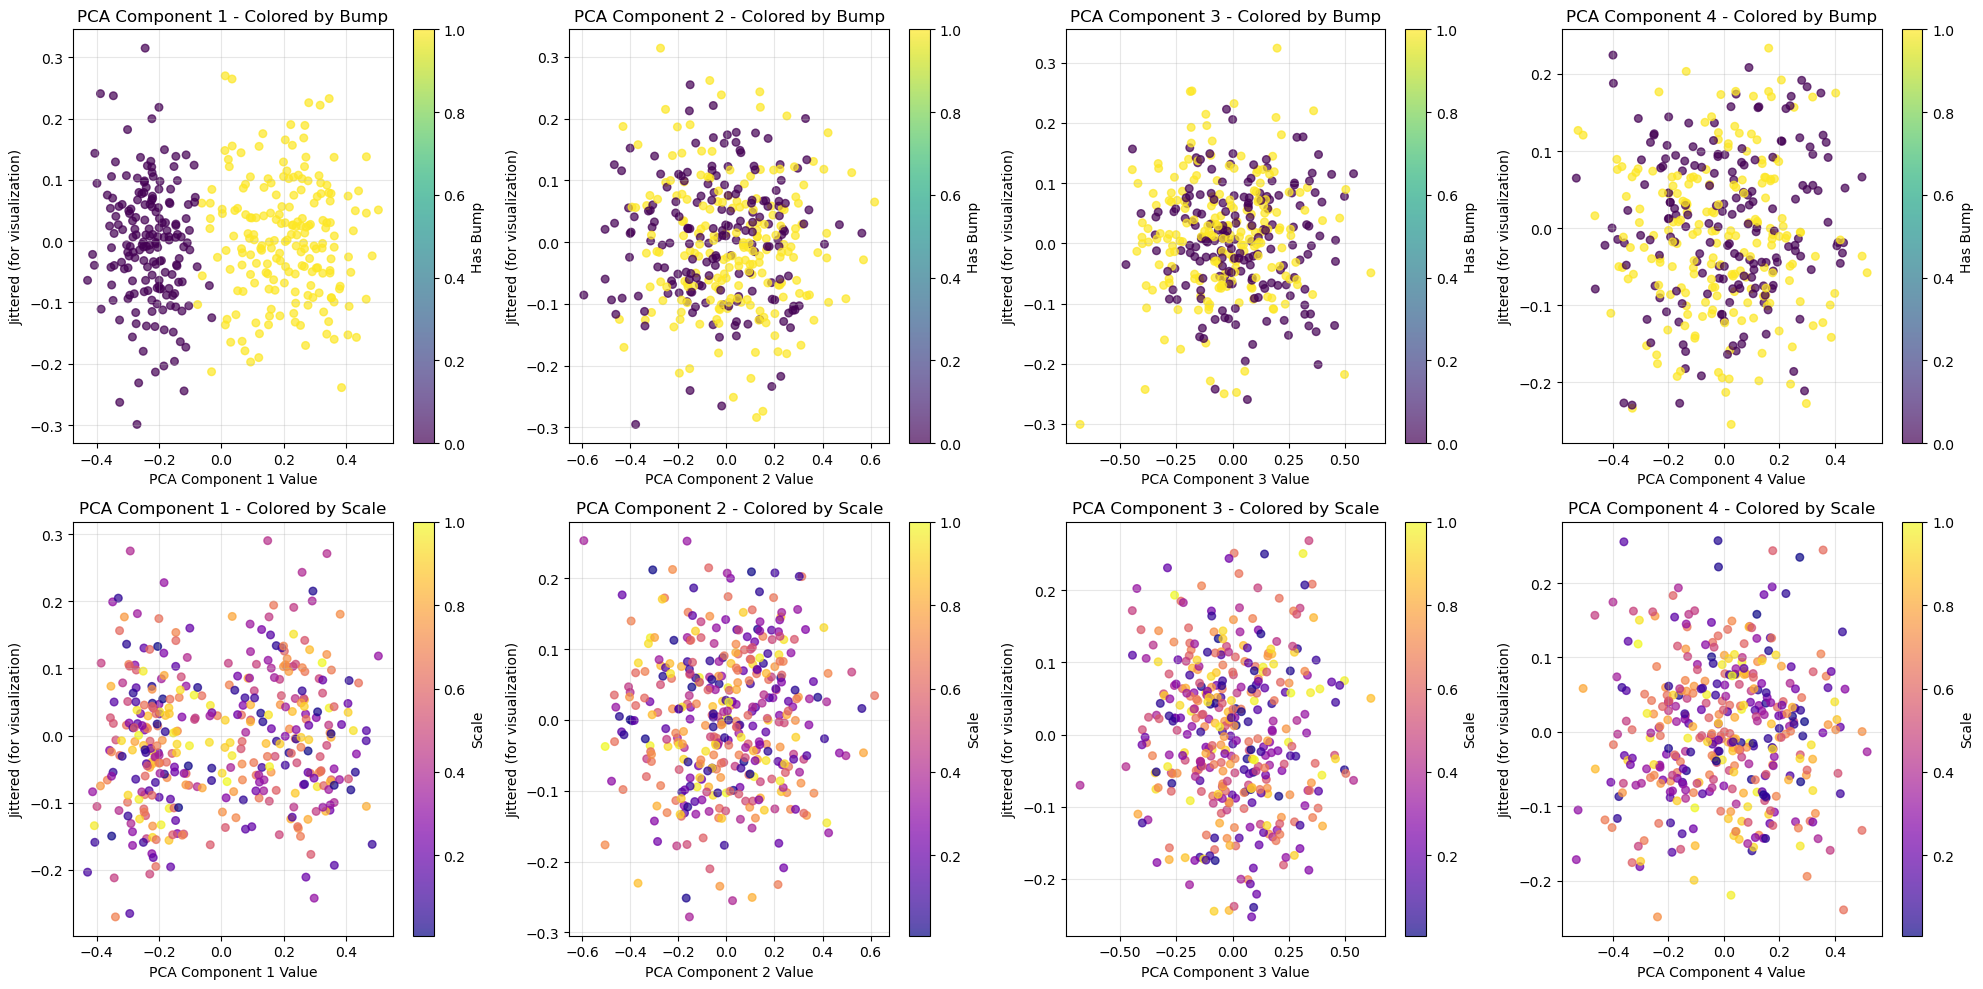

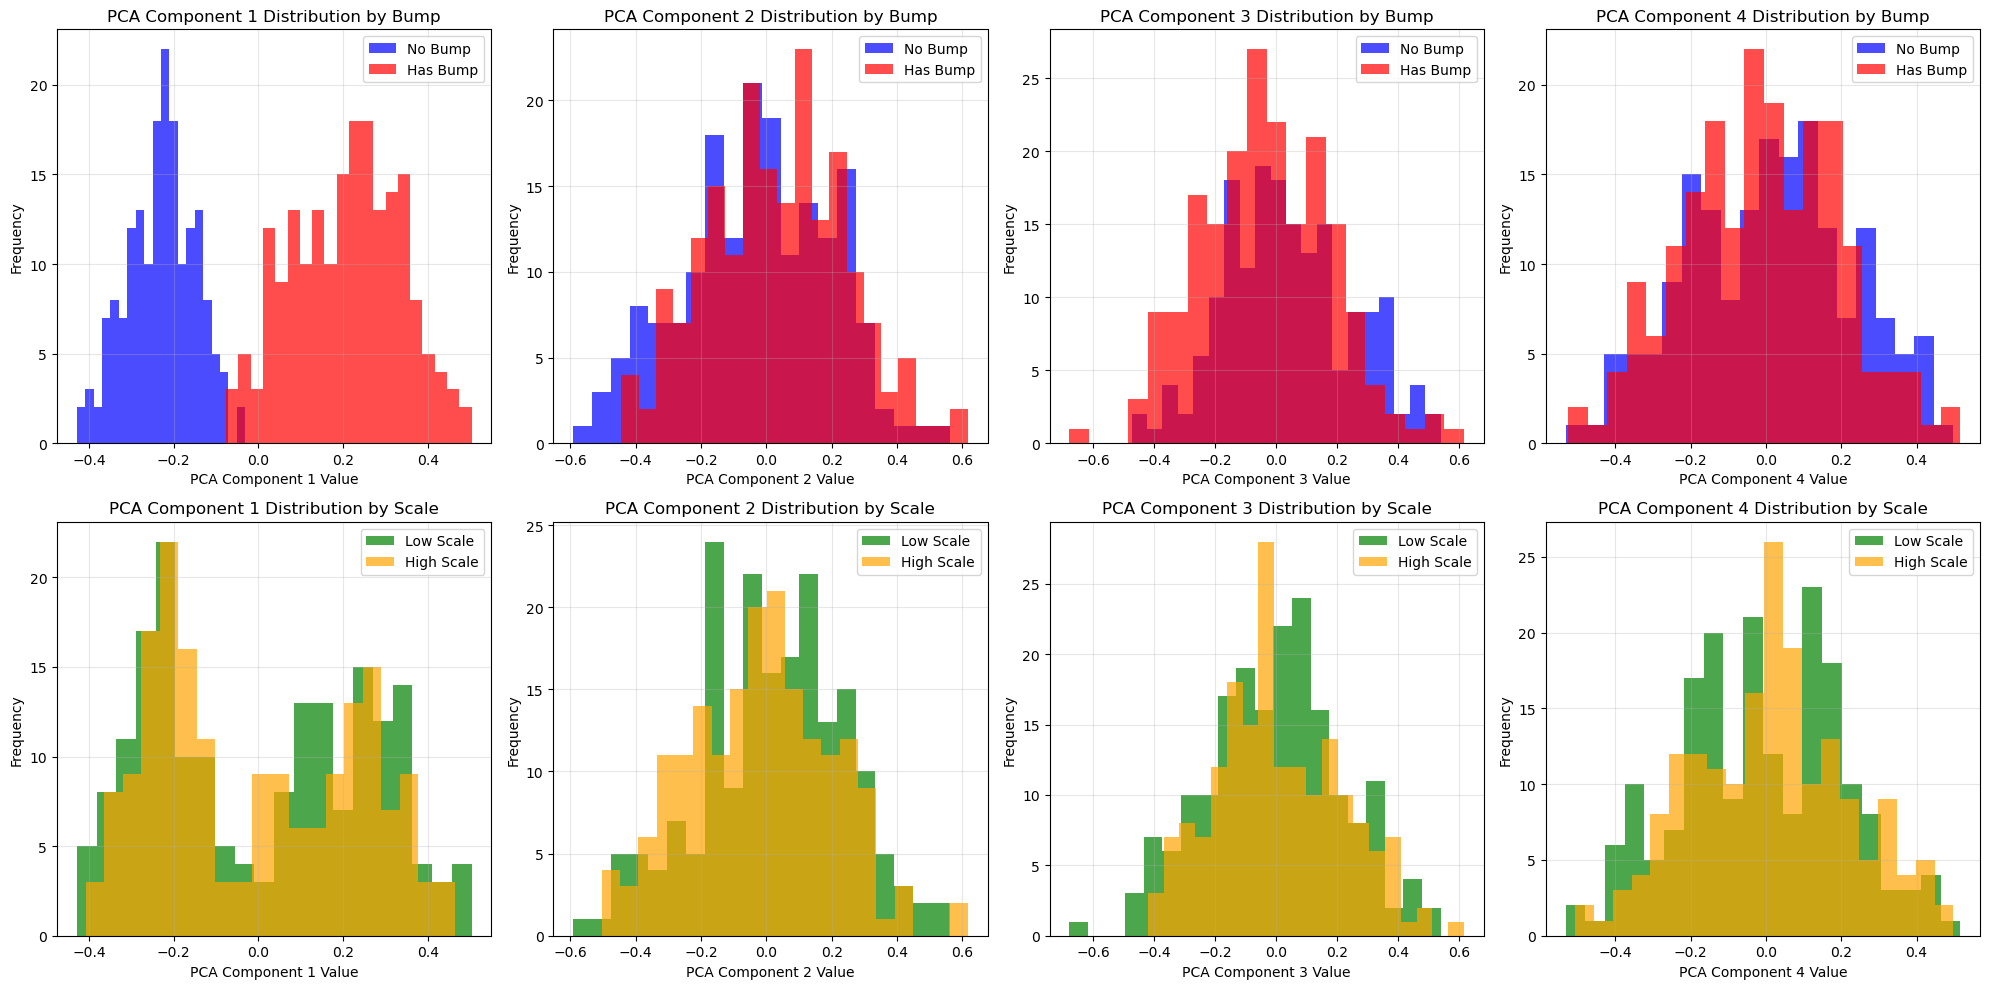


Detailed PCA Correlation Analysis:
PCA Component 1:
  Correlation with bump: 0.8973
  Correlation with scale: -0.0074
PCA Component 2:
  Correlation with bump: 0.1444
  Correlation with scale: -0.0395
PCA Component 3:
  Correlation with bump: -0.1751
  Correlation with scale: 0.0110
PCA Component 4:
  Correlation with bump: -0.0588
  Correlation with scale: -0.0105


In [ ]:
# Plot all 4 PCA components for bump and scale
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Get PCA results
pca_results = results["PCA"]

# Top row: All 4 components colored by bump
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[0, i].scatter(pca_results[:, i], jittered_y, c=has_bump, 
                                cmap='viridis', alpha=0.7, s=30)
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Jittered (for visualization)")
    axes[0, i].set_title(f"PCA Component {i+1} - Colored by Bump")
    axes[0, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0, i], label="Has Bump")

# Bottom row: All 4 components colored by scale
for i in range(4):
    jittered_y = np.random.normal(0, 0.1, len(pca_results))
    scatter = axes[1, i].scatter(pca_results[:, i], jittered_y, c=scales, 
                                cmap='plasma', alpha=0.7, s=30)
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Jittered (for visualization)")
    axes[1, i].set_title(f"PCA Component {i+1} - Colored by Scale")
    axes[1, i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, i], label="Scale")

plt.tight_layout()
plt.savefig("pca_all_components_vs_labels.png", dpi=300, bbox_inches='tight')
plt.show()

# Also create histogram distributions for all 4 PCA components
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

bump_mask = has_bump == 1
no_bump_mask = has_bump == 0

# Top row: Component distributions by bump
for i in range(4):
    component = pca_results[:, i]
    axes[0, i].hist(component[no_bump_mask], alpha=0.7, label='No Bump', 
                   bins=20, color='blue')
    axes[0, i].hist(component[bump_mask], alpha=0.7, label='Has Bump', 
                   bins=20, color='red')
    axes[0, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[0, i].set_ylabel("Frequency")
    axes[0, i].set_title(f"PCA Component {i+1} Distribution by Bump")
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Bottom row: Component distributions by scale (split into high/low scale)
scale_median = np.median(scales)
high_scale_mask = scales > scale_median
low_scale_mask = scales <= scale_median

for i in range(4):
    component = pca_results[:, i]
    axes[1, i].hist(component[low_scale_mask], alpha=0.7, label='Low Scale', 
                   bins=20, color='green')
    axes[1, i].hist(component[high_scale_mask], alpha=0.7, label='High Scale', 
                   bins=20, color='orange')
    axes[1, i].set_xlabel(f"PCA Component {i+1} Value")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].set_title(f"PCA Component {i+1} Distribution by Scale")
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_all_components_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Print correlation analysis for all 4 PCA components
print("\nDetailed PCA Correlation Analysis:")
for i in range(4):
    bump_corr = np.corrcoef(pca_results[:, i], has_bump)[0, 1]
    scale_corr = np.corrcoef(pca_results[:, i], scales)[0, 1]
    print(f"PCA Component {i+1}:")
    print(f"  Correlation with bump: {bump_corr:.4f}")
    print(f"  Correlation with scale: {scale_corr:.4f}")


Analyzing scale encoding across all 16 dimensions:
Latent dim 1: scale correlation = -0.1027
Latent dim 2: scale correlation = 0.0045
Latent dim 3: scale correlation = -0.1122
Latent dim 4: scale correlation = 0.0299
Latent dim 5: scale correlation = -0.0935
Latent dim 6: scale correlation = 0.0301
Latent dim 7: scale correlation = -0.0065
Latent dim 8: scale correlation = -0.0578
Latent dim 9: scale correlation = 0.0111
Latent dim 10: scale correlation = 0.0555
Latent dim 11: scale correlation = -0.0134
Latent dim 12: scale correlation = 0.0592
Latent dim 13: scale correlation = 0.0398
Latent dim 14: scale correlation = -0.0427
Latent dim 15: scale correlation = -0.0789
Latent dim 16: scale correlation = -0.0595

Linear regression R² for predicting scale from all 16 dimensions: 0.0600
This suggests scale information is poorly encoded in the full latent space


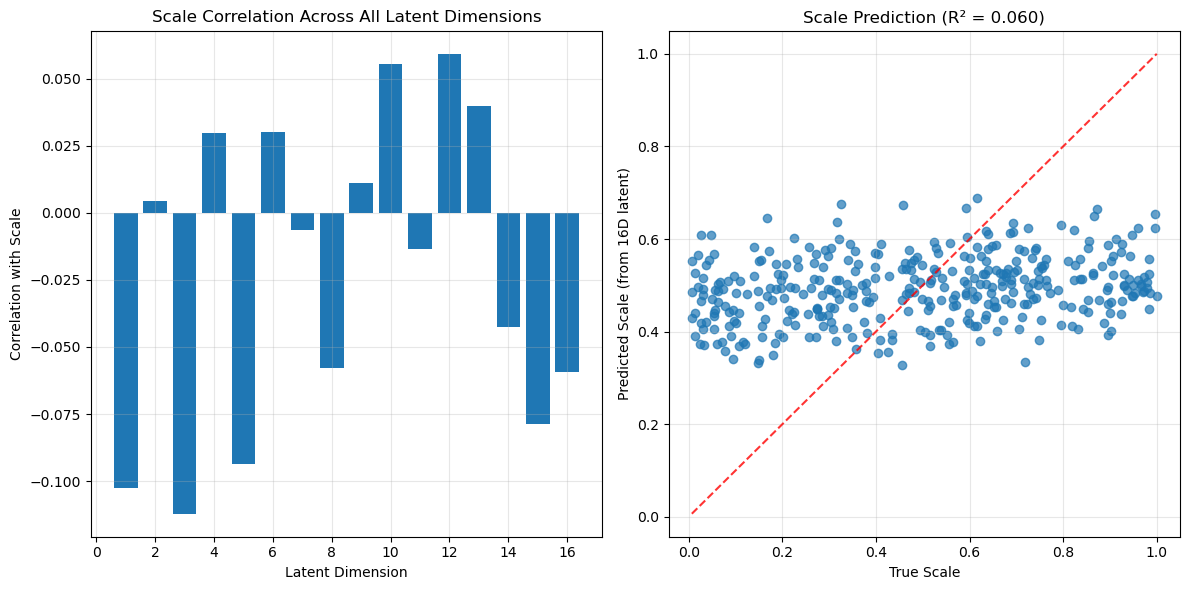

In [21]:
# Test if scale information is distributed across all dimensions
print("\nAnalyzing scale encoding across all 16 dimensions:")

# Calculate correlation of each individual latent dimension with scale
latent_scale_correlations = []
for dim in range(X.shape[1]):
    corr = np.corrcoef(X[:, dim], scales)[0, 1]
    latent_scale_correlations.append(corr)
    print(f"Latent dim {dim+1}: scale correlation = {corr:.4f}")

# Check if scale can be predicted using all 16 dimensions
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Train a linear model to predict scale from all 16 latent dimensions
lr = LinearRegression()
lr.fit(X, scales)
predicted_scales = lr.predict(X)
r2 = r2_score(scales, predicted_scales)

print(f"\nLinear regression R² for predicting scale from all 16 dimensions: {r2:.4f}")
print(f"This suggests scale information is {'well' if r2 > 0.7 else 'poorly'} encoded in the full latent space")

# Visualize the correlation pattern
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, 17), latent_scale_correlations)
plt.xlabel('Latent Dimension')
plt.ylabel('Correlation with Scale')
plt.title('Scale Correlation Across All Latent Dimensions')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(scales, predicted_scales, alpha=0.7)
plt.xlabel('True Scale')
plt.ylabel('Predicted Scale (from 16D latent)')
plt.title(f'Scale Prediction (R² = {r2:.3f})')
plt.plot([scales.min(), scales.max()], [scales.min(), scales.max()], 'r--', alpha=0.8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scale_analysis_full_latent_space.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Add this cell to your notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import seaborn as sns

# Unsupervised Clustering Analysis
print("=== UNSUPERVISED CLUSTERING ANALYSIS ===")

# Use your original 16D latent vectors
X_clustering = X.copy()  # Your original 16D latent vectors

# Standardize the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Dictionary to store clustering results
clustering_results = {}
cluster_metrics = {}

# 1. K-Means Clustering with different numbers of clusters
print("\n1. K-Means Clustering:")
k_range = range(2, 11)  # Try 2 to 10 clusters
kmeans_scores = {'silhouette': [], 'calinski': [], 'davies_bouldin': []}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate clustering metrics
    sil_score = silhouette_score(X_scaled, cluster_labels)
    cal_score = calinski_harabasz_score(X_scaled, cluster_labels)
    db_score = davies_bouldin_score(X_scaled, cluster_labels)
    
    kmeans_scores['silhouette'].append(sil_score)
    kmeans_scores['calinski'].append(cal_score)
    kmeans_scores['davies_bouldin'].append(db_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, Calinski-Harabasz={cal_score:.1f}, Davies-Bouldin={db_score:.3f}")
    
    if k == 3:  # Store 3-cluster result as example
        clustering_results['KMeans_3'] = cluster_labels
        cluster_metrics['KMeans_3'] = {'silhouette': sil_score, 'calinski': cal_score, 'davies_bouldin': db_score}

# Find optimal K for K-means
best_k_sil = k_range[np.argmax(kmeans_scores['silhouette'])]
best_k_cal = k_range[np.argmax(kmeans_scores['calinski'])]
best_k_db = k_range[np.argmin(kmeans_scores['davies_bouldin'])]

print(f"\nOptimal K by Silhouette: {best_k_sil}")
print(f"Optimal K by Calinski-Harabasz: {best_k_cal}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")

# Run K-means with the best K (by silhouette score)
best_kmeans = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_kmeans_labels = best_kmeans.fit_predict(X_scaled)
clustering_results['KMeans_Best'] = best_kmeans_labels

=== UNSUPERVISED CLUSTERING ANALYSIS ===

1. K-Means Clustering:
K=2: Silhouette=0.080, Calinski-Harabasz=32.0, Davies-Bouldin=3.342
K=3: Silhouette=0.076, Calinski-Harabasz=23.6, Davies-Bouldin=3.337
K=4: Silhouette=0.058, Calinski-Harabasz=20.7, Davies-Bouldin=3.507
K=5: Silhouette=0.060, Calinski-Harabasz=18.9, Davies-Bouldin=3.157
K=6: Silhouette=0.053, Calinski-Harabasz=17.4, Davies-Bouldin=3.022
K=7: Silhouette=0.051, Calinski-Harabasz=15.8, Davies-Bouldin=2.831
K=8: Silhouette=0.059, Calinski-Harabasz=15.0, Davies-Bouldin=2.768
K=9: Silhouette=0.050, Calinski-Harabasz=14.0, Davies-Bouldin=2.779
K=10: Silhouette=0.055, Calinski-Harabasz=13.6, Davies-Bouldin=2.673

Optimal K by Silhouette: 2
Optimal K by Calinski-Harabasz: 2
Optimal K by Davies-Bouldin: 10


In [15]:
# 2. Gaussian Mixture Model
print("\n2. Gaussian Mixture Model:")
gmm_scores = {'silhouette': [], 'aic': [], 'bic': []}

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    cluster_labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    aic_score = gmm.aic(X_scaled)
    bic_score = gmm.bic(X_scaled)
    
    gmm_scores['silhouette'].append(sil_score)
    gmm_scores['aic'].append(aic_score)
    gmm_scores['bic'].append(bic_score)
    
    print(f"K={k}: Silhouette={sil_score:.3f}, AIC={aic_score:.1f}, BIC={bic_score:.1f}")

# Find optimal K for GMM
best_k_gmm = k_range[np.argmax(gmm_scores['silhouette'])]
best_gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
best_gmm_labels = best_gmm.fit_predict(X_scaled)
clustering_results['GMM_Best'] = best_gmm_labels

# 3. DBSCAN Clustering
print("\n3. DBSCAN Clustering:")
# Try different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    if n_clusters > 1:  # Only calculate if we have valid clusters
        sil_score = silhouette_score(X_scaled, cluster_labels)
        dbscan_results.append((eps, n_clusters, n_noise, sil_score))
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, Silhouette={sil_score:.3f}")
    else:
        print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points (invalid)")

# Select best DBSCAN result
if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda x: x[3])  # Best by silhouette score
    best_eps = best_dbscan[0]
    
    dbscan_final = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = dbscan_final.fit_predict(X_scaled)
    clustering_results['DBSCAN_Best'] = dbscan_labels
    print(f"Best DBSCAN: eps={best_eps}, silhouette={best_dbscan[3]:.3f}")


2. Gaussian Mixture Model:
K=2: Silhouette=0.081, AIC=16657.8, BIC=17850.6
K=3: Silhouette=0.076, AIC=16792.8, BIC=18583.9
K=4: Silhouette=0.048, AIC=16843.3, BIC=19232.8
K=5: Silhouette=0.036, AIC=16942.3, BIC=19930.2
K=6: Silhouette=0.045, AIC=17059.2, BIC=20645.4
K=7: Silhouette=0.041, AIC=17155.7, BIC=21340.3
K=8: Silhouette=0.042, AIC=17244.0, BIC=22026.9
K=9: Silhouette=0.047, AIC=17436.4, BIC=22817.6
K=10: Silhouette=0.045, AIC=17567.1, BIC=23546.7

3. DBSCAN Clustering:
eps=0.3: 0 clusters, 369 noise points (invalid)
eps=0.5: 0 clusters, 369 noise points (invalid)
eps=0.7: 0 clusters, 369 noise points (invalid)
eps=1.0: 0 clusters, 369 noise points (invalid)
eps=1.5: 0 clusters, 369 noise points (invalid)
eps=2.0: 0 clusters, 369 noise points (invalid)


In [16]:
# 4. Hierarchical Clustering
print("\n4. Hierarchical Clustering:")
hier_linkages = ['ward', 'complete', 'average']
hier_results = {}

for linkage in hier_linkages:
    for k in [3, 4, 5]:
        hierarchical = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        cluster_labels = hierarchical.fit_predict(X_scaled)
        
        sil_score = silhouette_score(X_scaled, cluster_labels)
        hier_results[f'{linkage}_{k}'] = (cluster_labels, sil_score)
        print(f"Linkage={linkage}, K={k}: Silhouette={sil_score:.3f}")

# Find best hierarchical clustering
best_hier = max(hier_results.items(), key=lambda x: x[1][1])
clustering_results['Hierarchical_Best'] = best_hier[1][0]

# 5. Spectral Clustering
print("\n5. Spectral Clustering:")
spectral_results = {}

for k in [3, 4, 5]:
    spectral = SpectralClustering(n_clusters=k, random_state=42)
    cluster_labels = spectral.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, cluster_labels)
    spectral_results[k] = (cluster_labels, sil_score)
    print(f"K={k}: Silhouette={sil_score:.3f}")

# Find best spectral clustering
best_spectral = max(spectral_results.items(), key=lambda x: x[1][1])
clustering_results['Spectral_Best'] = best_spectral[1][0]


4. Hierarchical Clustering:
Linkage=ward, K=3: Silhouette=0.023
Linkage=ward, K=4: Silhouette=0.026
Linkage=ward, K=5: Silhouette=0.022
Linkage=complete, K=3: Silhouette=0.017
Linkage=complete, K=4: Silhouette=0.017
Linkage=complete, K=5: Silhouette=0.019
Linkage=average, K=3: Silhouette=0.054
Linkage=average, K=4: Silhouette=0.032
Linkage=average, K=5: Silhouette=0.019

5. Spectral Clustering:
K=3: Silhouette=0.048
K=4: Silhouette=0.013
K=5: Silhouette=-0.003



6. Visualization of Clustering Results:


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Using UMAP for visualization


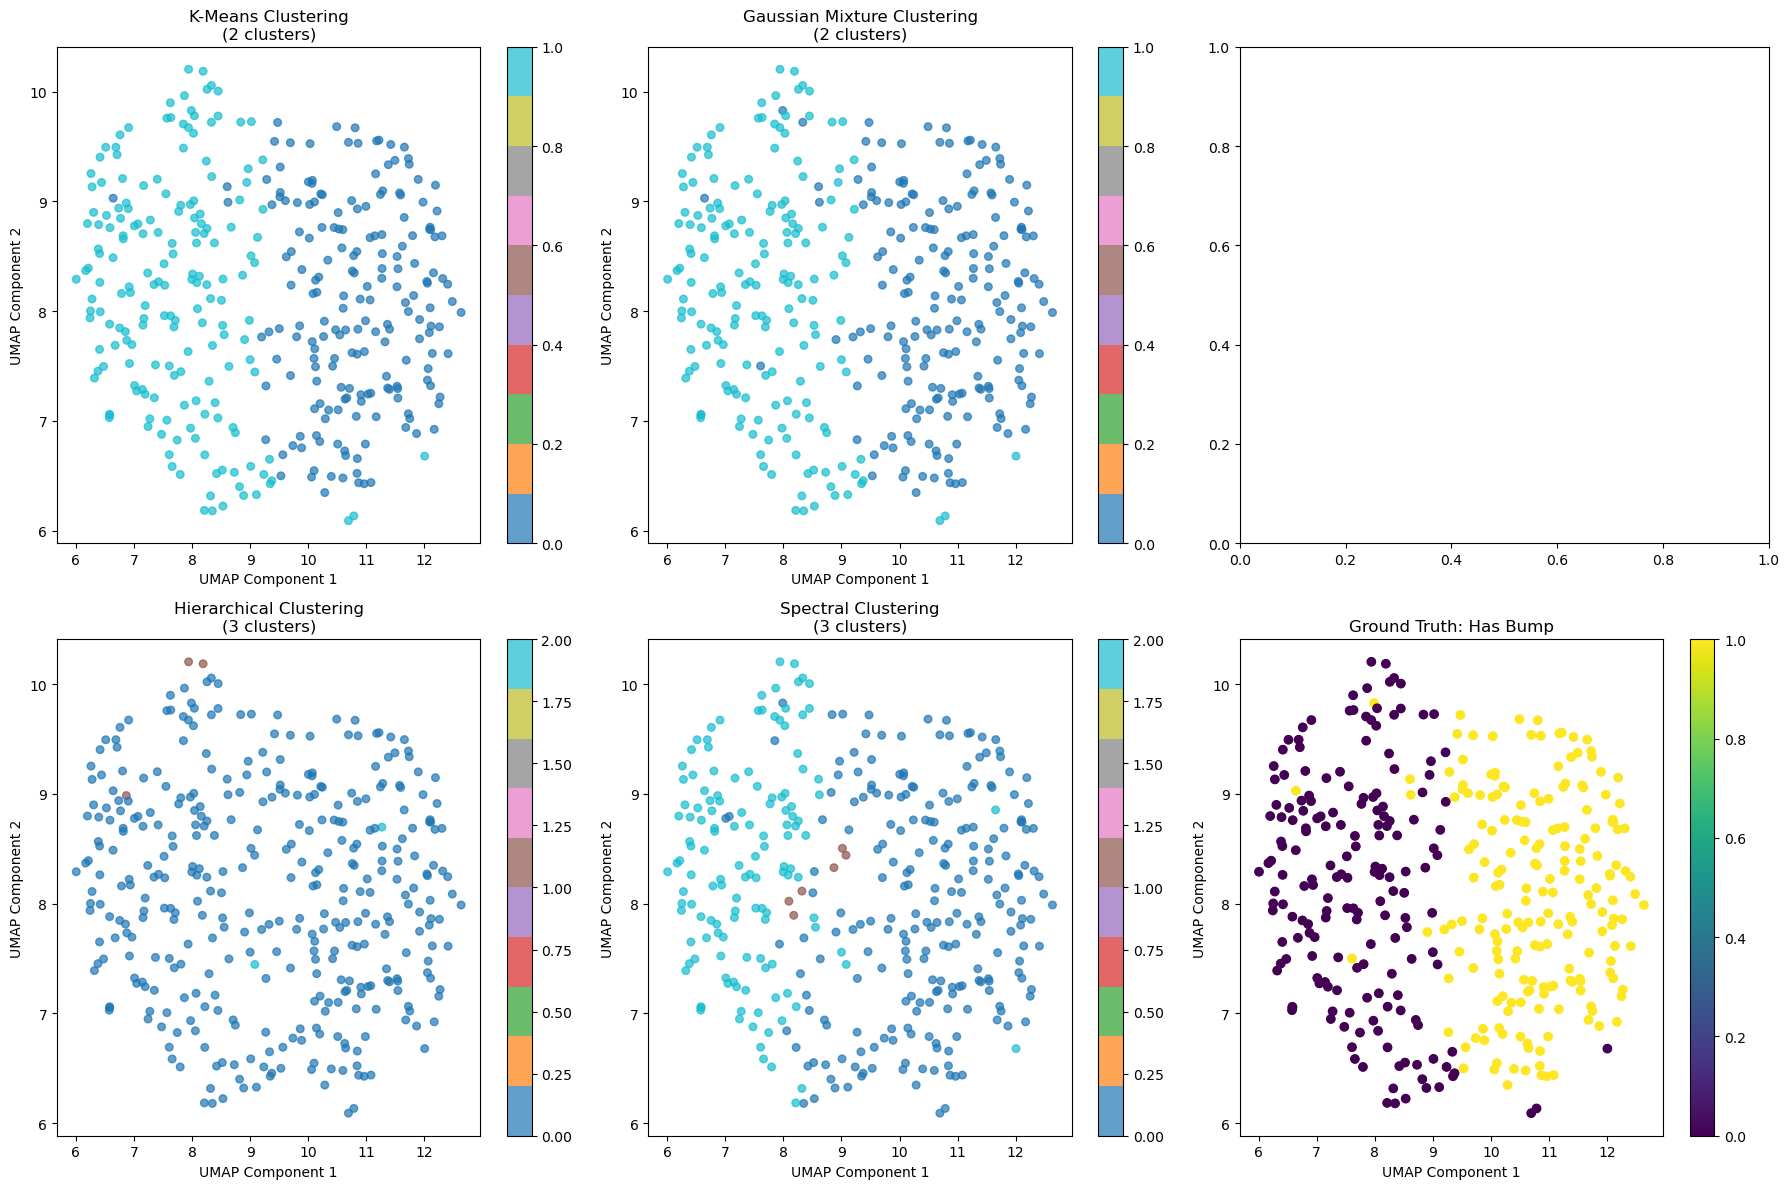

In [18]:
# 6. Visualize clustering results using dimensionality reduction
print("\n6. Visualization of Clustering Results:")

# Use UMAP for better visualization of clusters
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)
    print("Using UMAP for visualization")
except ImportError:
    # Fallback to t-SNE if UMAP is not available
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_umap = tsne.fit_transform(X_scaled)
    print("Using t-SNE for visualization")

# Plot clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

methods = ['KMeans_Best', 'GMM_Best', 'DBSCAN_Best', 'Hierarchical_Best', 'Spectral_Best']
method_names = ['K-Means', 'Gaussian Mixture', 'DBSCAN', 'Hierarchical', 'Spectral']

for i, (method, name) in enumerate(zip(methods, method_names)):
    if method in clustering_results:
        labels = clustering_results[method]
        scatter = axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=labels, 
                                 cmap='tab10', alpha=0.7, s=30)
        axes[i].set_title(f'{name} Clustering\n({len(set(labels))} clusters)')
        axes[i].set_xlabel('UMAP Component 1')
        axes[i].set_ylabel('UMAP Component 2')
        plt.colorbar(scatter, ax=axes[i])

# Compare with your known labels
axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis', alpha=0.7, s=30)
axes[5].set_title('Ground Truth: Has Bump')
axes[5].set_xlabel('UMAP Component 1')
axes[5].set_ylabel('UMAP Component 2')
plt.colorbar(axes[5].scatter(X_umap[:, 0], X_umap[:, 1], c=has_bump, cmap='viridis'), ax=axes[5])

plt.tight_layout()
plt.savefig("clustering_results_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 7. Analyze cluster characteristics
print("\n7. Cluster Analysis:")

# Analyze the best K-means clustering
best_labels = clustering_results['KMeans_Best']
unique_clusters = sorted(set(best_labels))

print(f"\nAnalyzing K-Means clustering with {len(unique_clusters)} clusters:")

cluster_analysis = {}
for cluster_id in unique_clusters:
    cluster_mask = best_labels == cluster_id
    
    # Analyze cluster characteristics
    cluster_bump_ratio = np.mean(has_bump[cluster_mask])
    cluster_scale_mean = np.mean(scales[cluster_mask])
    cluster_scale_std = np.std(scales[cluster_mask])
    cluster_size = np.sum(cluster_mask)
    
    cluster_analysis[cluster_id] = {
        'size': cluster_size,
        'bump_ratio': cluster_bump_ratio,
        'scale_mean': cluster_scale_mean,
        'scale_std': cluster_scale_std
    }
    
    print(f"Cluster {cluster_id}:")
    print(f"  Size: {cluster_size} samples")
    print(f"  Bump ratio: {cluster_bump_ratio:.3f}")
    print(f"  Scale mean±std: {cluster_scale_mean:.3f}±{cluster_scale_std:.3f}")

# 8. Create new labels from clustering
print("\n8. Creating Training Labels from Clusters:")

# You can use these cluster labels as new training targets
cluster_labels_for_training = best_labels

# Save the cluster assignments
np.save("unsupervised_cluster_labels.npy", cluster_labels_for_training)
print(f"Saved cluster labels to 'unsupervised_cluster_labels.npy'")
print(f"Shape: {cluster_labels_for_training.shape}")
print(f"Unique clusters: {sorted(set(cluster_labels_for_training))}")

# You can now use cluster_labels_for_training as your new training targets
# for any supervised learning task


7. Cluster Analysis:

Analyzing K-Means clustering with 2 clusters:
Cluster 0:
  Size: 190 samples
  Bump ratio: 1.000
  Scale mean±std: 0.493±0.280
Cluster 1:
  Size: 179 samples
  Bump ratio: 0.017
  Scale mean±std: 0.492±0.297

8. Creating Training Labels from Clusters:
Saved cluster labels to 'unsupervised_cluster_labels.npy'
Shape: (369,)
Unique clusters: [0, 1]


In [96]:
# Analyze original latent space statistics
print("Original 16D Latent Space Analysis:")
print("="*50)

for i in range(X.shape[1]):
    dim = X[:, i]
    print(f"Dimension {i+1}:")
    print(f"  Min: {dim.min():.4f}")
    print(f"  Max: {dim.max():.4f}")
    print(f"  Range: {dim.max() - dim.min():.4f}")
    print(f"  Average: {dim.mean():.4f}")
    print(f"  Std: {dim.std():.4f}")

# Overall statistics
print(f"\nOverall Latent Space:")
print(f"  Global Min: {X.min():.4f}")
print(f"  Global Max: {X.max():.4f}")
print(f"  Global Range: {X.max() - X.min():.4f}")
print(f"  Global Mean: {X.mean():.4f}")

Original 16D Latent Space Analysis:
Dimension 1:
  Min: -0.3330
  Max: 0.3084
  Range: 0.6414
  Average: -0.0008
  Std: 0.1026
Dimension 2:
  Min: -0.1252
  Max: 0.5610
  Range: 0.6862
  Average: 0.2016
  Std: 0.1346
Dimension 3:
  Min: -0.3024
  Max: 0.3996
  Range: 0.7020
  Average: 0.0299
  Std: 0.1315
Dimension 4:
  Min: -0.1949
  Max: 0.2634
  Range: 0.4583
  Average: 0.0172
  Std: 0.0835
Dimension 5:
  Min: 0.1731
  Max: 0.8285
  Range: 0.6554
  Average: 0.4206
  Std: 0.1237
Dimension 6:
  Min: -0.5761
  Max: 0.3393
  Range: 0.9154
  Average: -0.1228
  Std: 0.1824
Dimension 7:
  Min: -0.7796
  Max: -0.2717
  Range: 0.5079
  Average: -0.4867
  Std: 0.0994
Dimension 8:
  Min: -0.0314
  Max: 0.5314
  Range: 0.5628
  Average: 0.2397
  Std: 0.1066
Dimension 9:
  Min: -0.2466
  Max: 0.4723
  Range: 0.7189
  Average: -0.0041
  Std: 0.1168
Dimension 10:
  Min: -0.3684
  Max: 0.2590
  Range: 0.6273
  Average: -0.0705
  Std: 0.1329
Dimension 11:
  Min: 0.1847
  Max: 0.7637
  Range: 0.5790
